In [1]:
!pip -q install transformers accelerate datasets sentence-transformers pillow

In [2]:
from transformers import AutoProcessor

processor = AutoProcessor.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct"
)

print("Loaded Successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Loaded Successfully


In [3]:
import pandas as pd

df = pd.read_csv("processed_dataset.csv")

print(df.iloc[0]["cam_front"])
print(df.iloc[0]["question"])
print(df.iloc[0]["answer"])

../nuscenes/samples/CAM_FRONT/n008-2018-09-18-13-10-39-0400__CAM_FRONT__1537291010612404.jpg
What are objects to the front right of the ego car?
There are many barriers and one construction vehicle to the front right of the ego car.


In [4]:
!git clone https://github.com/OpenDriveLab/DriveLM.git

Cloning into 'DriveLM'...
remote: Enumerating objects: 6152, done.
remote: Counting objects: 100% (561/561), done.
remote: Compressing objects: 100% (274/274), done.
remote: Total 6152 (delta 396), reused 316 (delta 286), pack-reused 5591 (from 2)
Receiving objects: 100% (6152/6152), 280.55 MiB | 33.69 MiB/s, done.
Resolving deltas: 100% (3005/3005), done.


In [5]:
import os

img_path = "DriveLM/challenge/llama_adapter_v2_multimodal7b/data/nuscenes/samples/CAM_FRONT"

print(os.path.exists(img_path))

True


Image Size: (1600, 900)


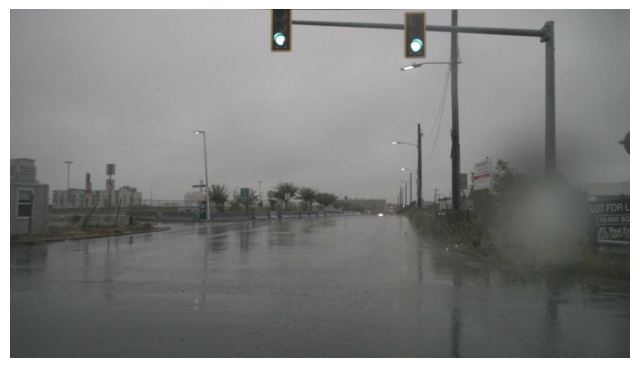

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = "DriveLM/challenge/llama_adapter_v2_multimodal7b/data/nuscenes/samples/CAM_FRONT/n008-2018-09-18-13-10-39-0400__CAM_FRONT__1537291010612404.jpg"

img = Image.open(img_path)

print("Image Size:", img.size)

plt.figure(figsize=(8,6))
plt.imshow(img)
plt.axis("off")
plt.show()

In [7]:
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
import torch

model_name = "Qwen/Qwen2-VL-2B-Instruct"

processor = AutoProcessor.from_pretrained(model_name)

model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("Model Loaded Successfully")

model.safetensors.index.json:   0%|          | 0.00/56.4k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

Model Loaded Successfully


In [9]:
question = "What are objects to the front right of the ego car?"
ground_truth = "There are many barriers and one construction vehicle to the front right of the ego car."

print(question)
print(ground_truth)

What are objects to the front right of the ego car?
There are many barriers and one construction vehicle to the front right of the ego car.


In [10]:
from PIL import Image
import torch

image = Image.open(
    "DriveLM/challenge/llama_adapter_v2_multimodal7b/data/nuscenes/samples/CAM_FRONT/n008-2018-09-18-13-10-39-0400__CAM_FRONT__1537291010612404.jpg"
)

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": question}
        ]
    }
]

text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = processor(
    text=[text],
    images=[image],
    padding=True,
    return_tensors="pt"
)

inputs = inputs.to(model.device)

with torch.no_grad():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=100
    )

generated_text = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)

print(generated_text[0])

system
You are a helpful assistant.
user
What are objects to the front right of the ego car?
assistant
The objects to the front right of the ego car are street signs and a traffic light.


In [11]:
sample_df = df.sample(20, random_state=42)

print(len(sample_df))

20


In [12]:
results = []

results.append({
    "question": question,
    "ground_truth": ground_truth,
    "prediction": generated_text[0]
})

import pandas as pd

results_df = pd.DataFrame(results)

results_df

,question,ground_truth,prediction
0,What are objects to the front right of the ego...,There are many barriers and one construction v...,system\nYou are a helpful assistant.\nuser\nWh...


In [13]:
generated_ids_trimmed = [
    out_ids[len(in_ids):]
    for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]

response = processor.batch_decode(
    generated_ids_trimmed,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False
)

print(response[0])

The objects to the front right of the ego car are street signs and a traffic light.


In [14]:
from PIL import Image
import torch
import time

def generate_answer(image_path, question):

    image = Image.open(image_path)

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": question}
            ]
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = processor(
        text=[text],
        images=[image],
        return_tensors="pt"
    )

    inputs = inputs.to(model.device)

    start = time.time()

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=100
        )

    latency = time.time() - start

    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]

    answer = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True
    )[0]

    return answer, latency

In [15]:
sample_df = df.sample(5, random_state=42)

sample_df[["question","answer"]]

,question,answer
511,"In this scenario, what are dangerous actions t...","Changing to the right lane, accelerating, and ..."
39,"Is <c2,CAM_BACK,864.2,468.3> a traffic sign or...",No.
211,"Is <c1,CAM_FRONT_LEFT,231.5,472.1> an object t...",No.
199,"Will <c1,CAM_FRONT_LEFT,231.5,472.1> be in the...",No.
235,What is the status of the trailers that are to...,"One of the trailers is parked, and one is moving."


In [16]:
print(df.iloc[0]["cam_front"])

../nuscenes/samples/CAM_FRONT/n008-2018-09-18-13-10-39-0400__CAM_FRONT__1537291010612404.jpg


In [17]:
raw_path = df.iloc[0]["cam_front"]

print(raw_path)

fixed_path = (
    "DriveLM/challenge/llama_adapter_v2_multimodal7b/data/"
    + raw_path.replace("../", "")
)

print(fixed_path)

import os
print(os.path.exists(fixed_path))

../nuscenes/samples/CAM_FRONT/n008-2018-09-18-13-10-39-0400__CAM_FRONT__1537291010612404.jpg
DriveLM/challenge/llama_adapter_v2_multimodal7b/data/nuscenes/samples/CAM_FRONT/n008-2018-09-18-13-10-39-0400__CAM_FRONT__1537291010612404.jpg
True


In [18]:
def resolve_image_path(relative_path):
    return (
        "DriveLM/challenge/llama_adapter_v2_multimodal7b/data/"
        + relative_path.replace("../", "")
    )

In [19]:
test_path = resolve_image_path(df.iloc[0]["cam_front"])

print(test_path)
print(os.path.exists(test_path))

DriveLM/challenge/llama_adapter_v2_multimodal7b/data/nuscenes/samples/CAM_FRONT/n008-2018-09-18-13-10-39-0400__CAM_FRONT__1537291010612404.jpg
True


In [20]:
sample_row = sample_df.iloc[0]

image_path = resolve_image_path(
    sample_row["cam_front"]
)

pred, latency = generate_answer(
    image_path,
    sample_row["question"]
)

print("QUESTION:")
print(sample_row["question"])

print("\nGROUND TRUTH:")
print(sample_row["answer"])

print("\nPREDICTION:")
print(pred)

print("\nLATENCY:")
print(latency)

QUESTION:
In this scenario, what are dangerous actions to take for the ego vehicle?

GROUND TRUTH:
Changing to the right lane, accelerating, and going ahead, and backing up are dangerous actions to take for the ego vehicle in this scenario.

PREDICTION:
In the image, the ego vehicle is approaching an intersection with a red traffic light. The dangerous actions for the ego vehicle include:

1. **Stopping at the red light**: The traffic light is currently red, indicating that the vehicle should stop. Stopping at the light ensures that the vehicle is not causing a traffic jam or delaying other vehicles.
2. **Avoiding sudden stops or starts**: Reducing speed and maintaining a safe distance from other vehicles can help prevent accidents.
3. **Checking for

LATENCY:
6.759535551071167


In [21]:
results = []

sample_df = df.sample(5, random_state=42)

for _, row in sample_df.iterrows():

    image_path = resolve_image_path(
        row["cam_front"]
    )

    pred, latency = generate_answer(
        image_path,
        row["question"]
    )

    results.append({
        "question": row["question"],
        "ground_truth": row["answer"],
        "prediction": pred,
        "latency": latency
    })

results_df = pd.DataFrame(results)

results_df

,question,ground_truth,prediction,latency
0,"In this scenario, what are dangerous actions t...","Changing to the right lane, accelerating, and ...","In the image, the ego vehicle is approaching a...",7.027980
1,"Is <c2,CAM_BACK,864.2,468.3> a traffic sign or...",No.,The image shows a wet road with traffic lights...,3.596993
2,"Is <c1,CAM_FRONT_LEFT,231.5,472.1> an object t...",No.,The image shows a rainy day with a foggy atmos...,7.118587
3,"Will <c1,CAM_FRONT_LEFT,231.5,472.1> be in the...",No.,The image shows a rainy day with a foggy or mi...,6.086874
4,What is the status of the trailers that are to...,"One of the trailers is parked, and one is moving.",The status of the trailers that are to the bac...,3.983123


In [22]:
results_df.to_csv(
    "baseline_results.csv",
    index=False
)

In [23]:
print(
    "Average Latency:",
    results_df["latency"].mean()
)

Average Latency: 5.562711334228515


In [24]:
!pip -q install sentence-transformers

In [25]:
from sentence_transformers import SentenceTransformer, util

sim_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [26]:
def semantic_similarity(gt, pred):

    emb1 = sim_model.encode(
        gt,
        convert_to_tensor=True
    )

    emb2 = sim_model.encode(
        pred,
        convert_to_tensor=True
    )

    return util.cos_sim(
        emb1,
        emb2
    ).item()

In [27]:
results_df["semantic_score"] = results_df.apply(
    lambda row:
    semantic_similarity(
        row["ground_truth"],
        row["prediction"]
    ),
    axis=1
)

In [28]:
results_df["semantic_score"].mean()

np.float64(0.26560327410697937)